# Cuaderno de estudio: arquitecturas profundas

## Redes densas, convolucionales, recurrentes y basadas en atención

Este cuaderno recopila y reorganiza las arquitecturas vistas en clase y en los apuntes:

- **Redes densas / MLP / Feedforward**
- **Redes convolucionales / CNN**
- **Redes recurrentes / RNN**
- **LSTM**
- **GRU**
- **Transformers**

El objetivo no es memorizar fórmulas sueltas, sino entender:

1. Qué tipo de dato maneja mejor cada arquitectura.
2. Cómo fluye la información dentro de la red.
3. Qué significan sus variables principales.
4. Qué aprende la red durante `model.fit()`.
5. Cómo se interpretan pesos, sesgos, mapas de características, memorias, compuertas, tokens y embeddings.


# 0. Idea general de todas las arquitecturas

Todas las redes neuronales profundas tienen una idea común:

```text
entrada X
↓
transformaciones con pesos y sesgos
↓
predicción ŷ
↓
comparación con y_real
↓
corrección de pesos durante el entrenamiento
```

La diferencia principal entre arquitecturas no está en `model.fit()`, sino en **cómo procesan la información**.

| Arquitectura | Mejor para | Idea central |
|---|---|---|
| MLP / Densa | Datos tabulares o vectores | Combina características con capas completamente conectadas. |
| CNN | Imágenes, señales con estructura local | Usa filtros que recorren la entrada y detectan patrones locales. |
| RNN | Secuencias | Procesa dato por dato y guarda una memoria temporal. |
| LSTM | Secuencias largas | Usa compuertas para decidir qué recordar, olvidar o entregar. |
| GRU | Secuencias largas con modelo más liviano | Usa menos compuertas que LSTM para actualizar memoria. |
| Transformer | Secuencias con relaciones globales | Usa atención para conectar directamente elementos lejanos. |


# 1. Redes densas / MLP / Feedforward

Una red densa, también llamada **MLP** o **Feedforward**, recibe datos de entrada, los combina con pesos, suma un sesgo y aplica una función de activación.

La fórmula general por capas es:

$$
h^{(0)} = x
$$

$$
h^{(l)} = \phi \left(W^{(l)}h^{(l-1)} + b^{(l)}\right)
$$

$$
\hat{y} = g\left(W^{(L)}h^{(L-1)} + b^{(L)}\right)
$$

Donde:

| Símbolo | Significado |
|---|---|
| $x$ | entrada original |
| $h^{(l)}$ | salida de la capa $l$ |
| $W^{(l)}$ | pesos de la capa $l$ |
| $b^{(l)}$ | sesgos de la capa $l$ |
| $\phi$ | función de activación, por ejemplo ReLU |
| $\hat{y}$ | predicción final |

La idea es que cada capa transforma la información y la pasa a la siguiente.


## 1.1 Diagrama de red densa: 2 entradas, 3 neuronas ocultas y 1 salida

A continuación se muestra el diagrama corregido de la red densa trabajado en los apuntes. Aquí sí se ve con claridad que las dos entradas $x_1$ y $x_2$ se conectan con las tres neuronas ocultas, y que las tres salidas ocultas se conectan con la salida final $\hat{y}$.

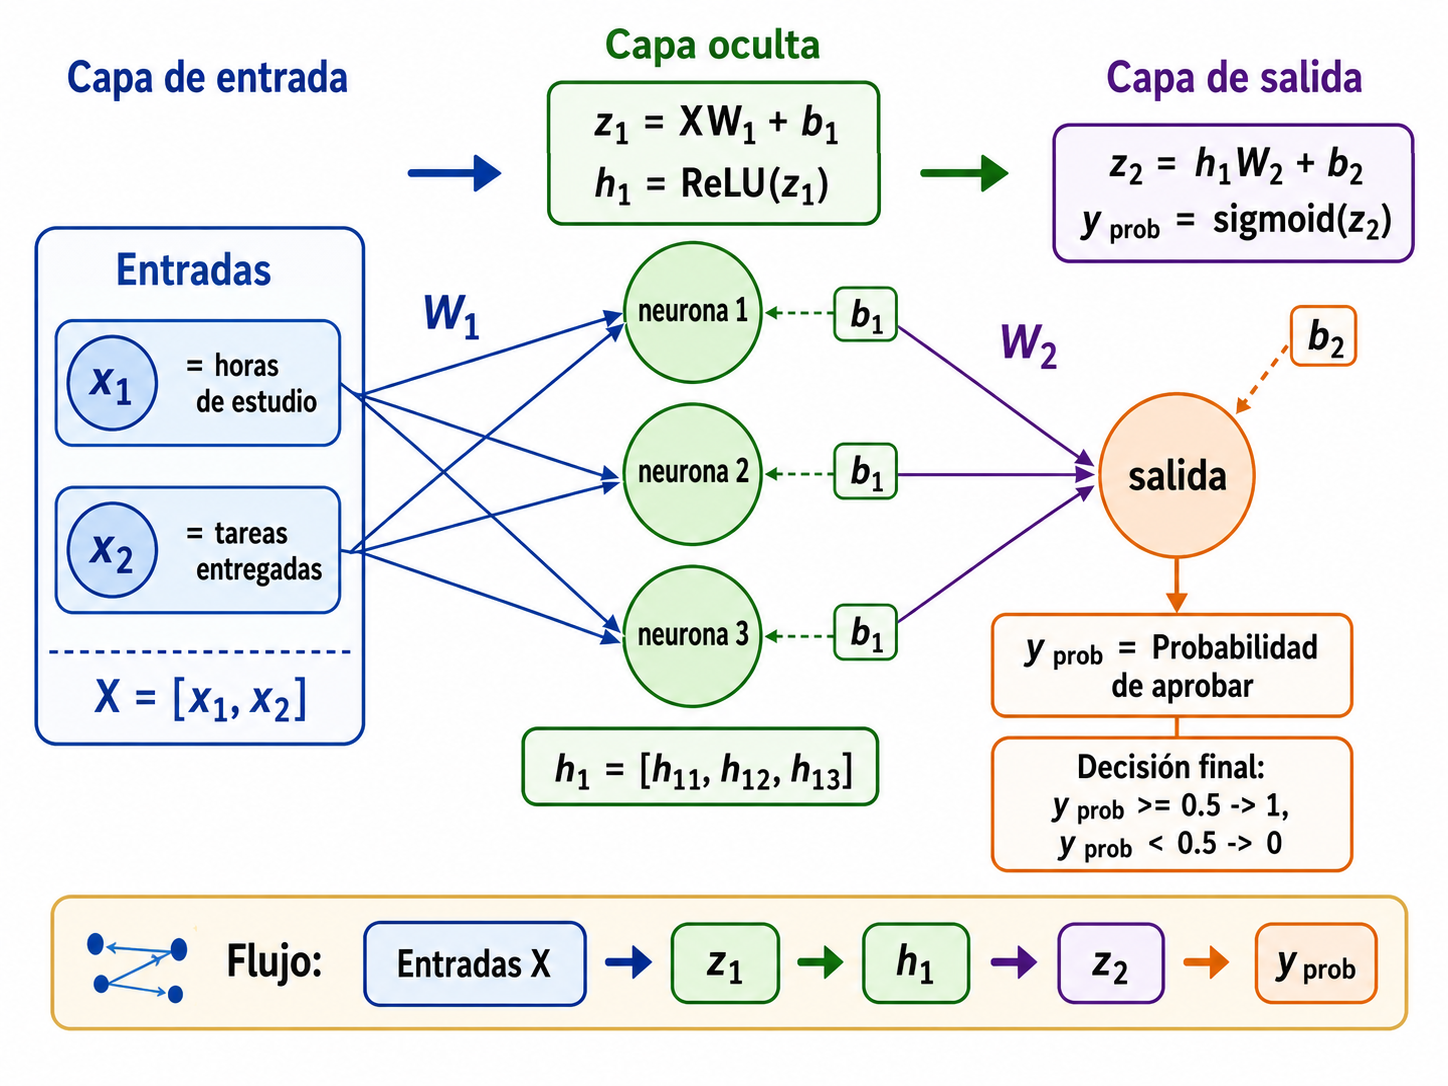

Lectura del diagrama:

- $x_1$ y $x_2$ son las dos entradas.
- La capa oculta tiene tres neuronas: $h_1$, $h_2$ y $h_3$.
- Cada entrada se conecta con cada neurona oculta, por eso aparecen 6 pesos en la primera capa.
- Las tres salidas ocultas se conectan con la neurona de salida, por eso aparecen 3 pesos adicionales en la salida.
- Cada neurona oculta tiene su sesgo, y la salida también tiene su propio sesgo.

Conexiones de entrada a capa oculta:

$$
W^{(1)}=
egin{bmatrix}
w_{11} & w_{12} & w_{13}\
w_{21} & w_{22} & w_{23}
\end{bmatrix}
$$

Usando la notación de los apuntes:

- $w_{11}$ conecta $x_1$ con la neurona $h_1$.
- $w_{12}$ conecta $x_1$ con la neurona $h_2$.
- $w_{13}$ conecta $x_1$ con la neurona $h_3$.
- $w_{21}$ conecta $x_2$ con la neurona $h_1$.
- $w_{22}$ conecta $x_2$ con la neurona $h_2$.
- $w_{23}$ conecta $x_2$ con la neurona $h_3$.

Cada neurona oculta tiene su propio sesgo:

$$
b^{(1)} = [b_1, b_2, b_3]
$$

Por tanto:

$$
z_1=x_1w_{11}+x_2w_{21}+b_1
$$

$$
z_2=x_1w_{12}+x_2w_{22}+b_2
$$

$$
z_3=x_1w_{13}+x_2w_{23}+b_3
$$

Después se aplica activación:

$$
h_1=\phi(z_1), \quad h_2=\phi(z_2), \quad h_3=\phi(z_3)
$$

Y la salida puede calcularse como:

$$
\hat{y}=g(h_1v_1+h_2v_2+h_3v_3+b_y)
$$

---


## 1.2 Qué contiene $h$ en una MLP

En una MLP, $h$ contiene las **salidas internas de una capa**.

Por ejemplo, si tenemos tres neuronas ocultas:

$$
h = [h_1, h_2, h_3]
$$

Ese vector resume lo que la capa oculta detectó o calculó a partir de la entrada.

Interpretación:

```text
entrada x
↓
capa oculta calcula h
↓
h se usa como entrada de la siguiente capa
```

Por eso en MLP se puede decir:

```text
h conecta capas.
```

No conecta tiempos. La arquitectura que conecta tiempos es RNN, LSTM o GRU.


## 1.3 Qué hacen los sesgos en MLP

La fórmula de una neurona densa es:

$$
z=w_1x_1+w_2x_2+b
$$

Luego:

$$
h=\phi(z)
$$

El sesgo $b$ permite desplazar la activación de la neurona.

Interpretación sencilla:

- Si $b$ es positivo, la neurona se activa más fácil.
- Si $b$ es negativo, la neurona necesita entradas más grandes para activarse.
- Se puede interpretar como un **umbral ajustable**.

Ejemplo con ReLU:

$$
z=2x+b
$$

Si $x=0.2$ y $b=-1$:

$$
z=2(0.2)-1=-0.6
$$

$$
ReLU(-0.6)=0
$$

La entrada era positiva, pero el sesgo negativo hizo que la neurona no se activara.

El sesgo también se aprende durante el entrenamiento:

$$
b_{nuevo}=b_{anterior}-\alpha \frac{\partial L}{\partial b}
$$


## 1.4 ¿Una MLP puede usar imágenes?

Sí puede, pero no es lo ideal.

Una MLP trabaja con **vectores de características**. Si la entrada ya es tabular, entra directo:

$$
x = [x_1, x_2, x_3]
$$

Pero si la entrada es una imagen, primero se debe aplanar.

Por ejemplo, una imagen de $28\times 28$ se convierte en:

$$
28\cdot 28 = 784
$$

```text
Imagen 28×28
↓
Flatten
↓
Vector de 784 valores
↓
MLP
```

La MLP sí puede procesar ese vector, pero al aplanar se pierde la estructura espacial.

Eso significa que la red ya no sabe naturalmente:

- qué píxel estaba arriba,
- qué píxel estaba abajo,
- qué píxel estaba al lado de otro,
- dónde hay bordes,
- dónde hay texturas,
- dónde hay formas locales.

Por eso las CNN son mejores para imágenes.


## 1.5 ¿Dónde se aplanan los datos?

Si los datos son imágenes y se quiere usar MLP, el aplanamiento puede hacerse antes del modelo:

```python
X_train = X_train.reshape(-1, 28*28)
X_test = X_test.reshape(-1, 28*28)
```

Si antes teníamos:

```text
(60000, 28, 28)
```

Después tenemos:

```text
(60000, 784)
```

También puede hacerse dentro del modelo:

```python
model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])
```

La línea importante es:

```python
Flatten()
```

En una CNN también se usa `Flatten`, pero normalmente **después** de las convoluciones y el pooling, no al inicio.


## 1.6 Por qué MLP no es la mejor opción para imágenes

Una MLP puede usar imágenes aplanadas, pero tiene varios problemas:

### 1. Pierde estructura espacial

Al convertir una imagen en un vector, se pierde la relación natural entre píxeles vecinos.

### 2. Necesita demasiados parámetros

Una imagen RGB de $224\times 224\times 3$ tiene:

$$
224\cdot 224\cdot 3 = 150528
$$

Si se conecta a una capa densa de 100 neuronas:

$$
150528\cdot 100 = 15052800
$$

Son más de quince millones de pesos solo en la primera capa.

En cambio, una CNN con 32 filtros de $3\times 3$ para una imagen RGB necesita:

$$
3\cdot 3\cdot 3\cdot 32 = 864
$$

más 32 sesgos:

$$
864+32=896
$$

### 3. Es más sensible a cambios de posición

Si un objeto se mueve un poco en la imagen, una MLP puede fallar porque aprendió posiciones específicas. Una CNN es más robusta porque el mismo filtro se desliza por toda la imagen.


In [ ]:
# Ejemplo: MLP para datos tabulares o imágenes ya aplanadas

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten

# Caso 1: datos tabulares, ya son vectores
model_tabular = Sequential([
    Input(shape=(3,)),          # 3 características de entrada
    Dense(8, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_tabular.compile(optimizer="adam", loss="binary_crossentropy")
model_tabular.summary()


# 2. Redes convolucionales / CNN

Una CNN está diseñada para trabajar con datos que tienen estructura local.

Ejemplos:

- imágenes,
- señales 1D,
- espectrogramas,
- mapas,
- matrices de sensores.

La idea principal es que una CNN no aplana la imagen al inicio. Primero usa filtros para detectar patrones locales.


## 2.1 Fórmula de convolución

La operación central de una CNN es:

$$
s(i,j)=\sum_m\sum_n x(i+m,j+n)k(m,n)
$$

Donde:

| Símbolo | Significado |
|---|---|
| $x$ | imagen o señal de entrada |
| $k$ | filtro o kernel |
| $s(i,j)$ | valor de salida en la posición $(i,j)$ |
| $i,j$ | posición donde está ubicado el filtro sobre la imagen |
| $m,n$ | índices internos del filtro |
| $x(i+m,j+n)$ | valor de la imagen que está debajo del filtro |
| $k(m,n)$ | valor del filtro en esa posición |

Interpretación:

```text
1. Tomar una región pequeña de la imagen.
2. Multiplicarla elemento a elemento por el filtro.
3. Sumar todos los productos.
4. Guardar el resultado en la posición (i,j) del mapa de características.
```

Un filtro funciona como un detector de patrones.


## 2.2 Ejemplo de convolución manual

Supongamos la región:

$$
R=
\begin{bmatrix}
1 & 1 & 0\\
1 & 1 & 0\\
0 & 0 & 1
\end{bmatrix}
$$

Y el filtro:

$$
K=
\begin{bmatrix}
1 & 0 & -1\\
1 & 0 & -1\\
1 & 0 & -1
\end{bmatrix}
$$

Multiplicamos elemento a elemento:

$$
R\odot K=
\begin{bmatrix}
1(1) & 1(0) & 0(-1)\\
1(1) & 1(0) & 0(-1)\\
0(1) & 0(0) & 1(-1)
\end{bmatrix}
$$

$$
R\odot K=
\begin{bmatrix}
1 & 0 & 0\\
1 & 0 & 0\\
0 & 0 & -1
\end{bmatrix}
$$

Ahora sumamos:

$$
1+0+0+1+0+0+0+0-1=1
$$

Entonces:

$$
s(i,j)=1
$$

Ese valor se guarda en el mapa de características.


## 2.3 Qué es un mapa de características

Un **mapa de características** es la salida que produce un filtro después de recorrer toda la imagen.

Si un filtro detecta bordes verticales, el mapa de características indica en qué zonas de la imagen aparecen bordes verticales.

Si un filtro detecta texturas, el mapa indica en qué zonas hay texturas similares.

Interpretación de los valores:

| Valor en el mapa | Interpretación |
|---|---|
| Alto positivo | La región se parece mucho al patrón del filtro. |
| Cercano a cero | La región casi no activa el filtro. |
| Negativo | La región puede representar el patrón opuesto o no coincidir. |

Después de ReLU:

$$
ReLU(x)=\max(0,x)
$$

los valores negativos se convierten en cero. Entonces el mapa queda como un detector de activaciones positivas.

```text
Mapa de características = dónde aparece el patrón que detecta un filtro.
```


## 2.4 Qué puede contener un mapa de características

En las primeras capas de una CNN, los mapas de características suelen representar patrones simples:

- bordes verticales,
- bordes horizontales,
- cambios de intensidad,
- esquinas,
- texturas básicas.

En capas más profundas, los mapas pueden representar patrones más complejos:

- partes de objetos,
- formas,
- regiones de interés,
- combinaciones de bordes y texturas,
- características útiles para clasificar.

Ejemplo:

```text
Imagen de una serpiente
↓
Primeros mapas: bordes, escamas, contraste
↓
Mapas profundos: formas del cuerpo, patrones de textura, cabeza, fondo
↓
Capa densa: decisión final
```

No siempre podemos decir exactamente qué representa cada mapa, pero sí podemos interpretarlo como una respuesta espacial a un patrón aprendido.


## 2.5 Canales y filtros

Si la entrada es una imagen en escala de grises, tiene forma:

$$
H\times W\times 1
$$

Si es una imagen RGB, tiene forma:

$$
H\times W\times 3
$$

Un filtro para imagen RGB no es solo $3\times 3$. Realmente es:

$$
3\times 3\times 3
$$

porque debe mirar los tres canales: rojo, verde y azul.

Si usamos 8 filtros, la salida tendrá 8 mapas de características:

$$
H'\times W'\times 8
$$

Regla:

```text
1 filtro produce 1 mapa de características.
8 filtros producen 8 mapas de características.
32 filtros producen 32 mapas de características.
```


## 2.6 Sesgo en CNN

La fórmula puede escribirse como:

$$
h=\phi(x*k+b)
$$

En CNN, el sesgo $b$ se suma normalmente al mapa de características de cada filtro.

Interpretación:

- Cada filtro aprende sus pesos $k$.
- Cada filtro puede tener su propio sesgo $b$.
- El sesgo ajusta qué tan fácil se activa ese filtro.

Si el sesgo es positivo, el filtro puede activarse más fácilmente.

Si el sesgo es negativo, la región debe coincidir más fuerte con el patrón para que la salida sea positiva después de ReLU.

```text
Sesgo en CNN = ajuste de activación para cada filtro.
```


## 2.7 Padding: qué es y cómo se interpreta

El **padding** consiste en agregar un borde alrededor de la imagen, normalmente con ceros.

Ejemplo:

$$
\begin{bmatrix}
1 & 1\\
1 & 1
\end{bmatrix}
$$

Con padding 1 queda:

$$
\begin{bmatrix}
0 & 0 & 0 & 0\\
0 & 1 & 1 & 0\\
0 & 1 & 1 & 0\\
0 & 0 & 0 & 0
\end{bmatrix}
$$

Interpretación:

El padding permite que el filtro pueda mirar mejor los bordes.

Sin padding, los píxeles de las esquinas participan menos en la convolución.

Con padding, el filtro puede colocarse también sobre regiones cercanas al borde.

También sirve para conservar el tamaño espacial de la salida.

Fórmula general:

$$
N_{salida}=\left\lfloor \frac{N+2P-F}{S} \right\rfloor + 1
$$

Donde:

| Símbolo | Significado |
|---|---|
| $N$ | tamaño de entrada |
| $P$ | padding |
| $F$ | tamaño del filtro |
| $S$ | stride |

Ejemplo:

$$
N=28, \quad F=3, \quad P=1, \quad S=1
$$

$$
N_{salida}=\left\lfloor \frac{28+2(1)-3}{1} \right\rfloor + 1=28
$$

Con padding 1, un filtro $3\times 3$ conserva el tamaño $28\times 28$.


## 2.8 Stride: qué es y cómo se interpreta

El **stride** es el salto con el que se mueve el filtro.

Si:

$$
S=1
$$

el filtro se mueve de uno en uno.

Si:

$$
S=2
$$

el filtro se mueve de dos en dos.

Interpretación:

- Stride pequeño: analiza más posiciones y conserva más detalle.
- Stride grande: reduce más rápido el tamaño y pierde detalle fino.

Ejemplo:

$$
N=28, \quad F=3, \quad P=0, \quad S=2
$$

$$
N_{salida}=\left\lfloor \frac{28-3}{2} \right\rfloor +1
$$

$$
N_{salida}=13
$$

La salida queda $13\times 13$.


## 2.9 Pooling y Flatten en CNN

### Pooling

El pooling reduce el tamaño de los mapas de características.

Ejemplo de MaxPooling $2\times 2$:

$$
\begin{bmatrix}
1 & 3\\
2 & 4
\end{bmatrix}
\rightarrow 4
$$

Interpretación:

```text
MaxPooling conserva la activación más fuerte de una región.
```

Sirve para:

- reducir tamaño,
- disminuir parámetros,
- conservar patrones importantes,
- hacer la red más robusta a pequeños desplazamientos.

### Flatten

Flatten aparece al final de la CNN para pasar de mapas a vector.

Ejemplo:

$$
13\times 13\times 8 = 1352
$$

```text
Mapas de características
↓
Flatten
↓
Vector
↓
Capa densa
```

La CNN no aplana al comienzo porque primero necesita extraer patrones espaciales.


In [ ]:
# CNN sencilla para ver formas de salida

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

model_cnn = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(filters=8, kernel_size=(3, 3), activation="relu", padding="valid"),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_cnn.summary()


# 3. Redes recurrentes / RNN

Las RNN sirven para datos donde el orden importa.

Ejemplos:

- series de tiempo,
- señales,
- texto,
- audio,
- sensores en el tiempo.

La fórmula principal de una RNN simple es:

$$
h_t=\phi(W_xx_t+W_hh_{t-1}+b_h)
$$

Y la salida puede ser:

$$
\hat{y}_t=g(W_yh_t+b_y)
$$

En una RNN:

```text
h conecta tiempos.
```

No conecta capas como en MLP.


## 3.1 Qué contiene la memoria $h_t$

El estado oculto $h_t$ contiene una representación de lo que la red ha visto hasta el tiempo $t$.

Ejemplo:

```text
x1 → h1
x2 + h1 → h2
x3 + h2 → h3
```

Interpretación:

- $h_1$ contiene información de $x_1$.
- $h_2$ contiene información de $x_1$ y $x_2$.
- $h_3$ contiene información acumulada de $x_1$, $x_2$ y $x_3$.

Por eso una RNN puede usar el último estado oculto para hacer una predicción final.


## 3.2 Sesgos en RNN

En la RNN:

$$
h_t=\phi(W_xx_t+W_hh_{t-1}+b_h)
$$

El sesgo $b_h$ desplaza la activación del estado oculto.

También puede existir un sesgo de salida:

$$
\hat{y}_t=g(W_yh_t+b_y)
$$

Interpretación:

- $b_h$ ajusta qué tan fácil se activa la memoria recurrente.
- $b_y$ ajusta la salida final.

Ambos se aprenden durante `model.fit()`.


## 3.3 Qué hace `model.fit()` en RNN

Cuando se llama:

```python
model.fit(X_train, y_train)
```

Keras hace internamente:

```text
1. Toma una secuencia.
2. Calcula h1, h2, h3, ...
3. Produce una predicción.
4. Compara con y_real.
5. Calcula el error.
6. Propaga el error hacia atrás en el tiempo.
7. Actualiza pesos y sesgos.
```

La actualización conceptual es:

$$
W_{nuevo}=W_{anterior}-\alpha \frac{\partial L}{\partial W}
$$

Para sesgos:

$$
b_{nuevo}=b_{anterior}-\alpha \frac{\partial L}{\partial b}
$$


In [ ]:
# RNN que aprende pesos para predecir el siguiente valor de una serie

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN, Dense

serie = np.arange(0, 100, dtype=float) / 100
window_size = 3

X, y = [], []
for i in range(len(serie) - window_size):
    X.append(serie[i:i+window_size])
    y.append(serie[i+window_size])

X = np.array(X).reshape(-1, window_size, 1)
y = np.array(y).reshape(-1, 1)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model_rnn = Sequential([
    Input(shape=(window_size, 1)),
    SimpleRNN(8, activation="tanh"),
    Dense(1)
])

model_rnn.compile(optimizer="adam", loss="mse")
model_rnn.summary()


# 4. LSTM

Una LSTM es una red recurrente mejorada para secuencias largas.

La RNN simple solo tiene una memoria principal:

$$
h_t
$$

La LSTM tiene dos estados:

| Estado | Interpretación |
|---|---|
| $h_t$ | estado oculto, lo que se entrega hacia afuera |
| $c_t$ | celda de memoria, memoria interna de largo plazo |

La LSTM usa compuertas para decidir:

- qué olvidar,
- qué guardar,
- qué entregar como salida.


## 4.1 Compuerta de olvido

La compuerta de olvido decide cuánto de la memoria anterior $c_{t-1}$ se conserva.

$$
f_t=\sigma(W_fx_t+U_fh_{t-1}+b_f)
$$

El valor $f_t$ está entre 0 y 1 porque pasa por una sigmoid.

Interpretación:

| Valor de $f_t$ | Qué significa |
|---|---|
| cercano a 0 | olvida casi toda la memoria anterior |
| cercano a 1 | conserva casi toda la memoria anterior |
| intermedio | conserva una parte y olvida otra |

¿Por qué puede ser cercano a 0 o 1?

Primero se calcula:

$$
z_f=W_fx_t+U_fh_{t-1}+b_f
$$

Luego:

$$
f_t=\sigma(z_f)
$$

Si $z_f$ es muy negativo:

$$
f_t\approx 0
$$

Si $z_f$ es muy positivo:

$$
f_t\approx 1
$$

`model.fit()` aprende los pesos $W_f$, $U_f$ y el sesgo $b_f$ para que esto ocurra en los momentos adecuados.


## 4.2 Compuerta de entrada y memoria candidata

La compuerta de entrada decide cuánta información nueva se guarda:

$$
i_t=\sigma(W_ix_t+U_ih_{t-1}+b_i)
$$

La memoria candidata propone nueva información:

$$
\tilde{c}_t=\tanh(W_cx_t+U_ch_{t-1}+b_c)
$$

Interpretación:

- $i_t$ decide cuánto se permite guardar.
- $\tilde{c}_t$ contiene la nueva información candidata.


## 4.3 Actualización de memoria interna

La memoria interna se actualiza así:

$$
c_t=f_t\odot c_{t-1}+i_t\odot \tilde{c}_t
$$

Esta ecuación tiene dos partes:

### Parte vieja

$$
f_t\odot c_{t-1}
$$

Indica cuánto de la memoria anterior se conserva.

### Parte nueva

$$
i_t\odot \tilde{c}_t
$$

Indica cuánto de la nueva memoria se agrega.

Interpretación global:

```text
memoria actual = memoria vieja filtrada + memoria nueva filtrada
```


## 4.4 Compuerta de salida

La compuerta de salida decide qué parte de la memoria interna se entrega hacia afuera como estado oculto.

$$
o_t=\sigma(W_ox_t+U_oh_{t-1}+b_o)
$$

Luego:

$$
h_t=o_t\odot \tanh(c_t)
$$

Interpretación:

- $c_t$ guarda memoria interna.
- $h_t$ es una versión filtrada de esa memoria.
- $h_t$ puede usarse para predecir o pasar información al siguiente tiempo.


## 4.5 Sesgos en LSTM

La LSTM tiene sesgos para varias compuertas:

| Compuerta | Sesgo |
|---|---|
| Olvido | $b_f$ |
| Entrada | $b_i$ |
| Memoria candidata | $b_c$ |
| Salida | $b_o$ |

Interpretación:

- El sesgo de olvido ayuda a inclinar la red a recordar u olvidar.
- El sesgo de entrada ayuda a controlar qué tan fácil se guarda información nueva.
- El sesgo de salida ayuda a decidir qué tan fácil se entrega información al exterior.

Todos se actualizan durante `model.fit()`.


## 4.6 Qué hace `model.fit()` en LSTM

`model.fit()` no dice manualmente:

```text
olvida aquí
recuerda aquí
guarda esto
entrega esto
```

Lo que hace es ajustar pesos y sesgos.

Durante entrenamiento:

```text
1. Entra una secuencia.
2. La LSTM calcula f_t, i_t, c̃_t, c_t, o_t y h_t.
3. Produce una predicción.
4. Compara con y_real.
5. Calcula el error.
6. Calcula gradientes.
7. Actualiza pesos y sesgos.
8. Repite.
```

Actualización conceptual:

$$
W_{nuevo}=W_{anterior}-\alpha\frac{\partial L}{\partial W}
$$

Con Adam en Keras, la corrección es adaptativa, pero sigue basada en gradientes.


In [ ]:
# LSTM equivalente al ejemplo de RNN

from tensorflow.keras.layers import LSTM

model_lstm = Sequential([
    Input(shape=(window_size, 1)),
    LSTM(8),
    Dense(1)
])

model_lstm.compile(optimizer="adam", loss="mse")
model_lstm.summary()

# Para entrenar:
# history = model_lstm.fit(X_train, y_train, epochs=200, batch_size=8,
#                          validation_data=(X_test, y_test))


# 5. GRU

La GRU también es una red recurrente con compuertas, pero más sencilla que LSTM.

GRU no separa claramente $h_t$ y $c_t$ como LSTM. Usa principalmente:

$$
h_t
$$

como memoria principal.

Tiene dos compuertas principales:

| Compuerta | Función |
|---|---|
| Actualización $z_t$ | decide cuánto conservar del pasado y cuánto actualizar |
| Reinicio $r_t$ | decide cuánto del pasado usar para crear la memoria candidata |


## 5.1 Compuerta de actualización

$$
z_t=\sigma(W_zx_t+U_zh_{t-1}+b_z)
$$

Interpretación:

- Si $z_t$ es pequeño, se conserva más la memoria anterior.
- Si $z_t$ es grande, se usa más la memoria nueva candidata.

Pregunta que responde:

```text
¿Mantengo lo que sabía o actualizo con lo nuevo?
```


## 5.2 Compuerta de reinicio

$$
r_t=\sigma(W_rx_t+U_rh_{t-1}+b_r)
$$

Interpretación:

- Si $r_t$ es pequeño, la GRU ignora más el pasado al crear la nueva memoria.
- Si $r_t$ es grande, la GRU usa más el pasado.

Pregunta que responde:

```text
¿Uso el pasado para construir la nueva memoria o lo reinicio?
```


## 5.3 Memoria candidata y memoria final

La memoria candidata es:

$$
\tilde{h}_t=\tanh(W_hx_t+U_h(r_t\odot h_{t-1})+b_h)
$$

Luego la memoria final se calcula como:

$$
h_t=(1-z_t)\odot h_{t-1}+z_t\odot \tilde{h}_t
$$

Interpretación:

```text
h_t = parte conservada del pasado + parte nueva agregada
```

Si $z_t=0$, se conserva la memoria anterior.

Si $z_t=1$, se reemplaza por la memoria candidata.


## 5.4 Sesgos en GRU

La GRU tiene sesgos para sus compuertas:

| Parte | Sesgo |
|---|---|
| Actualización | $b_z$ |
| Reinicio | $b_r$ |
| Memoria candidata | $b_h$ |

Interpretación:

Los sesgos desplazan las compuertas para facilitar o dificultar actualizar, reiniciar o conservar memoria.

También se aprenden durante `model.fit()`.


In [ ]:
# GRU equivalente al ejemplo de RNN y LSTM

from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Input(shape=(window_size, 1)),
    GRU(8),
    Dense(1)
])

model_gru.compile(optimizer="adam", loss="mse")
model_gru.summary()

# Para entrenar:
# history = model_gru.fit(X_train, y_train, epochs=200, batch_size=8,
#                         validation_data=(X_test, y_test))


# 6. Transformers

Un Transformer también trabaja con secuencias, pero no procesa elemento por elemento como una RNN.

En lugar de una memoria recurrente, usa **atención**.

La atención responde:

```text
Para entender este elemento, ¿a qué otros elementos debo prestar más atención?
```

La fórmula central es:

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

Pero antes de llegar a atención, necesitamos entender:

- tokens,
- IDs,
- embeddings,
- posición,
- máscaras.


## 6.1 Qué es un token

Un token es una unidad pequeña en la que se divide la entrada.

En texto, un token puede ser:

- una palabra,
- una parte de una palabra,
- un signo de puntuación,
- un símbolo especial.

Ejemplo:

```text
Estoy estudiando Transformers
```

Podría convertirse en:

```text
["Estoy", "estudiando", "Transformers"]
```

Pero también podría separarse en fragmentos:

```text
["Estoy", "estudi", "ando", "Transform", "ers"]
```

Eso depende del tokenizador.

El Transformer no trabaja directamente con texto. Primero trabaja con tokens.


## 6.2 Tokens, vocabulario e IDs

La red no puede multiplicar matrices con texto. Necesita números.

Por eso cada token se convierte en un ID numérico.

Ejemplo de vocabulario:

| Token | ID |
|---|---:|
| `<PAD>` | 0 |
| Estoy | 1 |
| estudiando | 2 |
| redes | 3 |
| neuronales | 4 |
| Transformers | 5 |

Entonces:

```text
Estoy estudiando Transformers
```

se convierte en:

```text
[1, 2, 5]
```

Importante:

El ID no es el significado del token. Solo es una etiqueta para buscar su representación numérica.


## 6.3 Qué es un embedding

Un embedding es un vector numérico que representa un token.

Ejemplo:

```text
"Transformers" → [0.12, -0.45, 0.88, 0.31]
```

El embedding no se escoge manualmente. Se aprende durante el entrenamiento.

Si el vocabulario tiene 6 tokens y cada embedding tiene dimensión 4:

$$
E\in \mathbb{R}^{6\times 4}
$$

Cada fila de $E$ corresponde a un token.

Si el token tiene ID 5, el modelo toma la fila 5 de la matriz de embeddings.

Interpretación:

```text
embedding = representación numérica aprendida de un token
```

Los embeddings permiten que tokens relacionados tengan representaciones útiles para el modelo.


## 6.4 Ejemplo completo de tokens a embeddings

Frase:

```text
Estoy estudiando Transformers
```

Tokenización:

```text
["Estoy", "estudiando", "Transformers"]
```

IDs:

```text
[1, 2, 5]
```

Si cada embedding tiene dimensión 4, podríamos tener:

$$
x_1=[0.70,-0.10,0.40,0.20]
$$

$$
x_2=[-0.30,0.80,0.10,-0.50]
$$

$$
x_3=[0.62,0.15,-0.21,0.47]
$$

La frase queda como una matriz:

$$
X=
\begin{bmatrix}
0.70 & -0.10 & 0.40 & 0.20\\
-0.30 & 0.80 & 0.10 & -0.50\\
0.62 & 0.15 & -0.21 & 0.47
\end{bmatrix}
$$

Forma:

$$
3\times 4
$$

porque hay 3 tokens y cada token tiene 4 valores.


## 6.5 Por qué el Transformer necesita posición

Una RNN procesa:

```text
x1 → x2 → x3
```

Entonces el orden está incluido en el proceso.

El Transformer procesa todos los tokens en paralelo. Por sí solo no sabe cuál fue primero, segundo o tercero.

Por eso se agrega información de posición.

La entrada final de cada token es:

$$
z_i=e_i+p_i
$$

Donde:

| Símbolo | Significado |
|---|---|
| $e_i$ | embedding del token |
| $p_i$ | embedding o codificación de posición |
| $z_i$ | representación final que entra al Transformer |

Ejemplo:

$$
e_1=[0.70,-0.10,0.40,0.20]
$$

$$
p_1=[0.01,0.02,0.03,0.04]
$$

Entonces:

$$
z_1=e_1+p_1=[0.71,-0.08,0.43,0.24]
$$

Ese vector ya indica:

```text
qué token es + en qué posición está
```


## 6.6 Embeddings de posición

Hay dos formas comunes de codificar posición:

### Posición fija

Se calcula con funciones matemáticas, como senos y cosenos.

La idea es dar a cada posición un patrón distinto.

### Posición aprendible

El modelo aprende una tabla de posiciones, igual que aprende la tabla de embeddings de tokens.

Ejemplo:

```text
posición 1 → p1
posición 2 → p2
posición 3 → p3
```

Si son aprendibles, también se actualizan durante `model.fit()`.


## 6.7 Padding y máscaras en Transformers

En un lote, las frases suelen necesitar la misma longitud.

Ejemplo:

```text
Frase 1: [Estoy, estudiando, Transformers]
Frase 2: [Hola]
```

Para igualar tamaños:

```text
Frase 1: [Estoy, estudiando, Transformers]
Frase 2: [Hola, <PAD>, <PAD>]
```

El token `<PAD>` es relleno. No debe considerarse información real.

Por eso se usa una máscara:

```text
Hola → válido
PAD → ignorar
PAD → ignorar
```

La máscara evita que la atención use posiciones de relleno.

En modelos generativos también se puede usar una máscara causal, que evita mirar tokens futuros.


## 6.8 De embeddings a Q, K y V

Una vez tenemos los embeddings con posición, formamos una matriz $Z$.

A partir de $Z$, el Transformer calcula:

$$
Q=ZW_Q
$$

$$
K=ZW_K
$$

$$
V=ZW_V
$$

Donde:

| Símbolo | Significado |
|---|---|
| $Q$ | consultas: qué busca cada token |
| $K$ | claves: qué ofrece cada token |
| $V$ | valores: información que se combina |

Interpretación:

```text
Q pregunta: ¿qué necesito?
K responde: ¿qué tengo?
V entrega: esta es mi información útil
```


## 6.9 Interpretación de la fórmula de atención

La fórmula es:

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

### Paso 1: $QK^T$

Mide qué tanto se relaciona cada token con los demás.

### Paso 2: dividir por $\sqrt{d_k}$

Evita que los valores sean demasiado grandes y estabiliza el cálculo.

### Paso 3: softmax

Convierte los puntajes en pesos entre 0 y 1.

Ejemplo:

$$
[0.1, 0.7, 0.2]
$$

significa:

```text
10% de atención al primer token
70% de atención al segundo token
20% de atención al tercer token
```

### Paso 4: multiplicar por $V$

Combina la información de los tokens según la atención asignada.


## 6.10 Multi-Head Attention

Un Transformer no usa una sola atención. Usa varias en paralelo.

Eso se llama **Multi-Head Attention**.

Interpretación:

```text
una cabeza puede mirar relaciones locales
otra puede mirar dependencias largas
otra puede mirar estructura gramatical
otra puede mirar patrones globales
```

En señales o series:

```text
una cabeza puede mirar tendencia
otra puede mirar periodicidad
otra puede mirar cambios bruscos
otra puede mirar relaciones lejanas
```

Luego las salidas de las cabezas se combinan.


## 6.11 Feed Forward, Add & Norm y sesgos en Transformer

Después de la atención, el Transformer suele tener:

```text
Multi-Head Attention
↓
Add & Norm
↓
Feed Forward
↓
Add & Norm
```

### Feed Forward

Es una pequeña red densa aplicada a cada token.

Sirve para transformar las características después de la atención.

### Add & Norm

`Add` significa que se suma la entrada original con la salida del bloque. Esto se llama conexión residual.

`Norm` estabiliza los valores internos.

### Sesgos

En Transformers hay sesgos en:

- proyecciones para crear $Q$, $K$, $V$,
- capa de salida de atención,
- capas feed-forward,
- a veces en embeddings o normalizaciones dependiendo de la implementación.

Interpretación:

Los sesgos desplazan las proyecciones y ayudan a ajustar la atención y transformación de características.


## 6.12 Tokens en imágenes: Vision Transformer

En texto, los tokens suelen ser palabras o partes de palabras.

En imágenes, un Vision Transformer divide la imagen en parches.

Ejemplo:

```text
Imagen
↓
patch 1, patch 2, patch 3, ...
↓
cada patch se convierte en un vector
↓
se agregan posiciones
↓
Transformer
```

Así como en texto:

```text
palabras → tokens
```

En imagen:

```text
parches → tokens
```


## 6.13 Qué hace `model.fit()` en Transformer

`model.fit()` entrena los parámetros del Transformer.

Ajusta:

- embeddings de tokens,
- embeddings de posición, si son aprendibles,
- $W_Q$, $W_K$, $W_V$,
- pesos de Multi-Head Attention,
- pesos y sesgos de Feed Forward,
- parámetros de normalización, si aplica.

Proceso:

```text
1. Entran tokens.
2. Se convierten en embeddings.
3. Se suma la posición.
4. Se calculan Q, K y V.
5. Se calcula atención.
6. Se pasa por Feed Forward.
7. Se produce una predicción.
8. Se compara con y_real.
9. Se calculan gradientes.
10. Se actualizan pesos, sesgos y embeddings.
```

La actualización conceptual sigue siendo:

$$
W_{nuevo}=W_{anterior}-\alpha\frac{\partial L}{\partial W}
$$

Para embeddings:

$$
E_{nuevo}=E_{anterior}-\alpha\frac{\partial L}{\partial E}
$$


In [ ]:
# Ejemplo conceptual de embedding en Keras

from tensorflow.keras.layers import Embedding

vocab_size = 10000       # cantidad de tokens posibles
embedding_dim = 128      # tamaño del vector por token
sequence_length = 20     # tokens por secuencia

embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=embedding_dim
)

# Entrada esperada: (batch_size, sequence_length)
# Salida del embedding: (batch_size, sequence_length, embedding_dim)

print("Si entran 32 frases de 20 tokens:")
print("Entrada: (32, 20)")
print("Salida del embedding: (32, 20, 128)")


# 7. `model.fit()` y actualización de pesos en todas las arquitecturas

Una idea clave de todo el cuaderno es que `model.fit()` aparece en todas las arquitecturas.

La razón es que `fit()` es el método general de Keras para entrenar modelos.

Lo que cambia es la arquitectura:

```text
MLP → Dense
CNN → Conv2D + Pooling + Dense
RNN → SimpleRNN + Dense
LSTM → LSTM + Dense
GRU → GRU + Dense
Transformer → Embedding + Attention + Feed Forward
```

Pero el entrenamiento siempre sigue esta lógica:

```text
entrada
↓
predicción
↓
comparación con y_real
↓
cálculo del error
↓
gradientes
↓
actualización de pesos
```


## 7.1 Actualización básica

La actualización conceptual de un peso es:

$$
W_{nuevo}=W_{anterior}-\alpha\frac{\partial L}{\partial W}
$$

Donde:

| Símbolo | Significado |
|---|---|
| $W_{anterior}$ | peso antes de actualizar |
| $W_{nuevo}$ | peso después de actualizar |
| $\alpha$ | tasa de aprendizaje |
| $L$ | función de pérdida |
| $\frac{\partial L}{\partial W}$ | gradiente del error respecto al peso |

Para sesgos:

$$
b_{nuevo}=b_{anterior}-\alpha\frac{\partial L}{\partial b}
$$

Para embeddings:

$$
E_{nuevo}=E_{anterior}-\alpha\frac{\partial L}{\partial E}
$$


## 7.2 Qué cambia cuando usamos Adam

En Keras se suele usar:

```python
model.compile(optimizer="adam", loss="mse")
```

Adam no usa exactamente la actualización simple:

$$
W-\alpha\frac{\partial L}{\partial W}
$$

sino una versión adaptativa.

Adam guarda promedios del gradiente y del gradiente al cuadrado:

$$
m_t=\beta_1m_{t-1}+(1-\beta_1)g_t
$$

$$
v_t=\beta_2v_{t-1}+(1-\beta_2)g_t^2
$$

Luego actualiza de forma adaptativa:

$$
W_t=W_{t-1}-\alpha\frac{\hat{m}_t}{\sqrt{\hat{v}_t}+\epsilon}
$$

Pero la idea de fondo es la misma:

```text
calcular error → calcular gradientes → corregir parámetros
```


# 8. Cuadro comparativo final

| Arquitectura | Entrada típica | Qué aprende | Qué conserva mejor | Qué puede perder si se usa mal | Sesgo |
|---|---|---|---|---|---|
| MLP | Vectores, datos tabulares | Pesos densos | Relaciones entre características | Estructura espacial o temporal si se aplana todo | Umbral ajustable de cada neurona |
| CNN | Imágenes, señales locales | Filtros, mapas y pesos densos | Estructura espacial/local | Relaciones globales si la red es muy pequeña | Ajuste de activación por filtro |
| RNN | Secuencias | Pesos de entrada, recurrentes y salida | Orden temporal corto | Dependencias largas | Ajusta activación de memoria |
| LSTM | Secuencias largas | Pesos de compuertas y memorias | Dependencias largas | Puede ser más pesada | Ajusta compuertas de olvidar/guardar/salir |
| GRU | Secuencias largas | Pesos de actualización y reinicio | Dependencias temporales con menos parámetros que LSTM | Puede ser menos expresiva en algunos casos | Ajusta actualización y reinicio |
| Transformer | Tokens de texto, parches de imagen, secuencias | Embeddings, atención, feed-forward | Relaciones globales entre elementos | Necesita posición y más datos/cómputo | Ajusta proyecciones y transformaciones |


# 9. Frases clave para recordar

- **MLP trabaja con vectores.** Si recibe imágenes o secuencias estructuradas, normalmente se aplanan, pero se pierde estructura.
- **CNN detecta patrones locales.** Sus mapas de características dicen dónde aparecen los patrones aprendidos por los filtros.
- **Padding permite mirar bordes y controlar el tamaño de salida.**
- **Stride controla el salto del filtro.** A mayor stride, menor tamaño de salida.
- **RNN conecta tiempos con $h_t$.**
- **LSTM usa $c_t$ y compuertas para recordar u olvidar.**
- **GRU usa menos compuertas que LSTM y actualiza una memoria principal $h_t$.**
- **Transformer usa tokens, embeddings, posición y atención.**
- **`model.fit()` aprende pesos, sesgos, embeddings y compuertas ajustando gradientes.**
